In [ ]:
# sampo.schemas.schedule - конструктор для готового расписания
# sampo.scheduler.genetic - алгоритм с начальной инциализацией

# from sampo.scheduler.genetic import GeneticScheduler
# from sampo.api.genetic_api import ScheduleGenerationScheme

# GeneticScheduler(sgs_type=ScheduleGenerationScheme.Serial).schedule(wg,contractors)[0]

In [25]:
import os
from sampo.schemas.graph import WorkGraph
from sampo_api import contractor
from scripts.wg_converter import WorkGraphConverter, ProjectConverter
from scripts.valid import run_heuristic, resource_profiles, check_feasibility
from scripts.metrics import distance_matrices

plt.rcParams['axes.grid'] = False

def read_file(path='wgs/small_synth', file='wg_9', contractors_N=5):  
    wg = WorkGraph.loadf(path, file)
    contractors = contractor(N = contractors_N)
    conv = WorkGraphConverter()
    data = conv.convert(wg, contractors)['rcpsp_data']
    return data

def validate_structures(base_path):
    data = read_file()
    res = []
    files = [f for f in os.listdir(base_path) if f != 'Steps']
    for file in files:
        try:
            schedule, _, resource_usage, job_usage, _  = run_heuristic(base_path, file, data)
            name = (file , file.split(' ')[-1])
        except:
            continue
        if not check_feasibility(schedule, job_usage, resource_usage, data):
            continue
        resource_profile = resource_profiles(schedule, resource_usage)
        res.append((name, resource_profile, schedule))

    print (f'Originality after test case:  {round( len(res) * 100 / len(files) )} %')
    heuristics, D_contractor, D_interval, D_resource, D_order = distance_matrices(res)
    D_total = D_contractor + D_interval + D_resource + D_order
    return heuristics, D_contractor, D_interval, D_resource, D_order, D_total

    

No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Error executing code for method Minimum Total Float Rule (TF): local variable '_enforce_time_limit' referenced before assignment
Error executing code for method Minimum Number of Successors Rule (MNS): Deadlock detected: no feasible schedule possible
Originality after test case:  73 %
Originality after matrix filter:  100 %
Acceptable for populations: (LFT), (MS), (SPT), (MRD), (LPT), (MXS), (MRS), (EST).


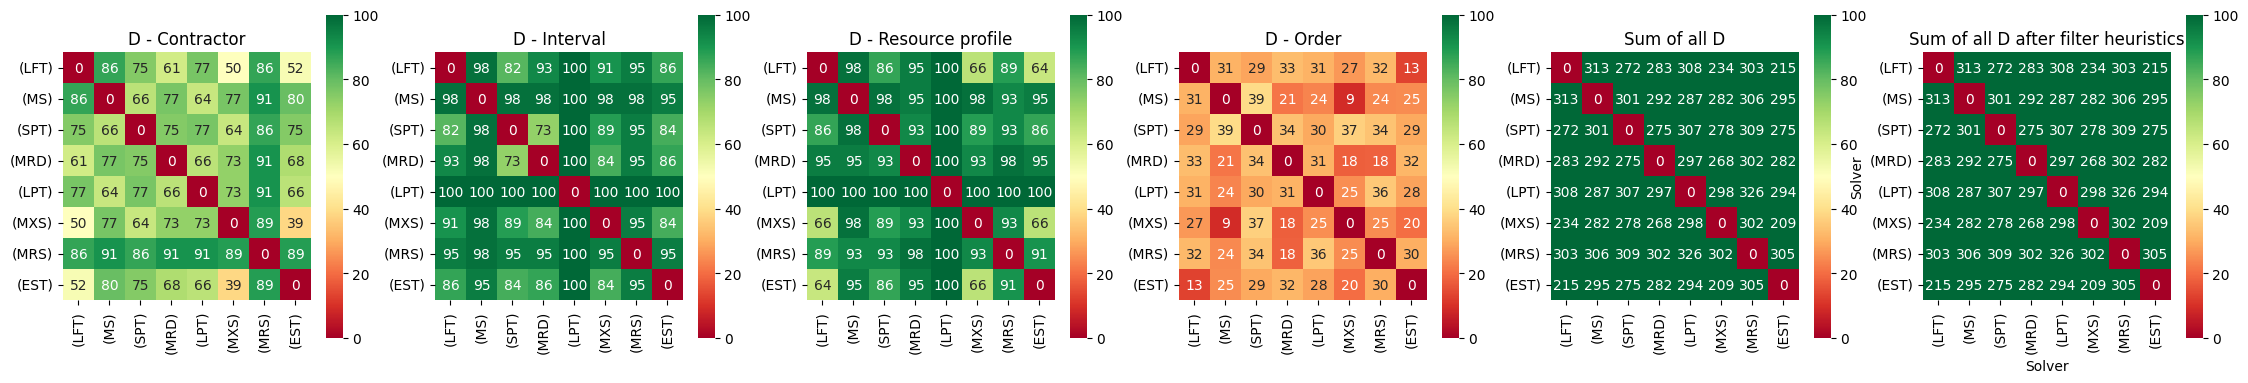

In [ ]:
from scripts.valid import *
from collections import defaultdict
from scripts.wg_converter import *
from sampo_api import *
from scripts.metrics import distance_matrices

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json 


def save_filter(path, names):
    with open(os.path.join(path, 'original_heuristics.json'), "w", encoding="utf-8") as f:
        json.dump(names, f, ensure_ascii=False, indent=2)

def plot_heatmap(axes, metrics, labels, orig_labels, 
                 titles = ['D - Contractor', 'D - Interval', 'D - Resource profile', 'D - Order', 
          'Sum of all D', 'Sum of all D after filter heuristics'], vmin=0.0, vmax=100.0):
    for i, metric in enumerate(metrics):
        labels = orig_labels if i == 5 else labels
        sns.heatmap(metric*100, xticklabels=labels, yticklabels=labels, cmap="RdYlGn", 
                    vmin=vmin, vmax=vmax, annot=True, fmt=".0f", square=True, ax=axes[i], 
                    cbar_kws={"shrink": 0.3, "pad": 0.05})
        axes[i].set_title(titles[i])
        plt.xlabel("Solver")
        plt.ylabel("Solver")
def get_filtered_row_indices(D):
    n = D.shape[0]
    # маска внедиагональных элементов
    mask_non_diag = ~np.eye(n, dtype=bool)
    # маска внедиагональных нулей (с учётом float)
    mask_offdiag_zero = D!= 0 & mask_non_diag
    keys = [tuple(row.astype(int)) for row in mask_offdiag_zero]
    seen = set()
    keep = []
    for i in range(n):
        key = keys[i]
        if key not in seen:
            keep.append(i)
            seen.add(key)
    return set(keep)
def estimate_algorithms(D_total, solvers):
    original_idx  = get_filtered_row_indices(D_total)
    original_heuristics = []
    for i, s in enumerate(solvers):
        if i in original_idx:
            original_heuristics.append(s)

    print (f'Originality after matrix filter:  {round( len(original_heuristics) * 100 / len(solvers) )} %')
    print('Acceptable for populations: ' + ', '.join(original_heuristics) +'.')
    return original_idx, original_heuristics


# deepseek_reasoner_control
# Папка для проверок сгенерированных скриптов и сэмпл (проект для теста)
# gpt_oss_120b, deepseek_reasoner, deepseek_chat
base_path = 'Heuristics/gpt_oss_120b'
heuristics, D_contractor, D_interval, D_resource, D_order, D_total = validate_structures(base_path)
idx, original_heuristics = estimate_algorithms(D_total, heuristics)

metrics = (D_contractor, D_interval, D_resource, D_order,
   D_total, D_total[list(idx)][:, list(idx)])

_, axes = plt.subplots(ncols=6, nrows=1, figsize = (28,14) )

plot_heatmap(axes, metrics, heuristics, original_heuristics)

save_filter(base_path, original_heuristics)

# for ax_row in axes: # TODO: nrows > 1
#     plot_heatmap(ax_row, metrics, heuristics, original_heuristics)





In [3]:
original_heuristics

['(LFT)', '(MS)', '(SPT)', '(MRD)', '(LPT)', '(MXS)', '(MRS)', '(EST)']

In [4]:
# def validate_structures(base_path):
#     data = read_file()
#     res = []
#     files = [f for f in os.listdir(base_path) if f != 'Steps']
#     for file in files:
#         schedule, _, resource_usage, _  = run_heuristic(base_path, file, data)
#         print(resource_usage)
#         name = file.split(' ')[-1]
#         resource_profile = resource_profiles(schedule,resource_usage)
#         res.append( (name, resource_profile, schedule) )

#     heuristics, D_contractor, D_interval, D_resource, D_order = distance_matrices(res)
#     D_total = D_contractor + D_interval + D_resource + D_order
#     return heuristics, D_contractor, D_interval, D_resource, D_order, D_total


# validate_structures(base_path)

# Check 1 - Сравнения между LLM-сгенерированными эвристиками
Обозначим множество всех решателей через $S$, а проект через $J$.
Каждому решателю $A \in S$ сопоставлено решение (расписание) по всем
ограничениям и переменным проекта $J$.

Для пары решений $A, B \in S$ введём метрику расстояния $d(A,B)$ как
сумму четырёх компонент:

$$
d(A,B)
=
d_{\text{contractor}}(A,B)
+
d_{\text{interval}}(A,B)
+
d_{\text{resource}}(A,B)
+
d_{\text{order}}(A,B).
$$

Поскольку все решатели рассматривают один и тот же проект $J$, 
множество работ (переменных/активностей) одинаково для всех решений.
Тогда для любой пары решателей $A,B \in S$:

$$
J_A = J_B = J,
\qquad
J_{AB} = J.
$$

1. Доля различий по подрядчикам

$$
d_{\text{contractor}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
c_{A,j} \neq c_{B,j}
\right].
$$

2. Доля различий по интервалам

$$
d_{\text{interval}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
\left(t^{\text{start}}_{A,j}, t^{\text{end}}_{A,j}\right)
\neq
\left(t^{\text{start}}_{B,j}, t^{\text{end}}_{B,j}\right)
\right].
$$

3. Доля различий по ресурсным профилям

$$
d_{\text{resource}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
\text{res\_profile}_A(j)
\neq
\text{res\_profile}_B(j)
\right].
$$

4. Доля различий по относительному порядку работ (на основе коэффицента Кендалла)

Сначала введём функцию знака:

$$
\operatorname{sgn}(x) =
\begin{cases}
-1, & x < 0,\\
0, & x = 0,\\
1, & x > 0.
\end{cases}
$$

Тогда

$$
d_{\text{order}}(A,B)
=
\frac{1}{\binom{| J |}{2}}
\sum_{\substack{i,j \in J \\ i < j}}
\mathbf{1}\!\left[
\operatorname{sgn}\!\bigl(t^{\text{start}}_{A,i} - t^{\text{start}}_{A,j}\bigr)
\neq
\operatorname{sgn}\!\bigl(t^{\text{start}}_{B,i} - t^{\text{start}}_{B,j}\bigr)
\right].
$$  

1-3 метрики на основе метрики Хэмминга

# Check 2 - Сравнения со структурой SAMPO эвристических решателей
# TODO

In [5]:
# TODO, сравнить как по структуре отличается с тем, что выдает SAMPO

# Estimate 0  - GAP с начальной популяцией из SAMPO

In [ ]:
from sampo_api import *
from sampo.scheduler.genetic.operators import TimeFitness
from scripts.valid import *

def estimate_llm_heuristics(filter, base_path, project_conv, data):
    files = [f for f in os.listdir(base_path) if f not in ('Steps', 'original_heurisitics.json')]
    makespan_list = []
    for file in files:
        name = file.split(' ')[-1]
        if name not in filter: 
            continue
        schedule, order, _, job_usage, makespan  = run_heuristic(base_path, file, data)
        try:
            chromosome = project_conv.to_chromosome(schedule, order, job_usage, makespan)
        except: 
            continue
        if project_conv.is_valid_chromosome(chromosome):
            makespan_list.append(makespan)
    return makespan_list


#def compare_sampo()

def estimate_sampo_population(wg, contractors):
    makespan_list = []
    init_choromosome = first_population(wg, contractors)
    toolbox = create_mvp_toolbox(wg, contractors)
    f = TimeFitness()
    for chrom_d in init_choromosome.items():
        (_, (chrom, _, _)) = chrom_d
        fitness = f.evaluate(chrom, evaluator=toolbox.evaluate_chromosome)[0]
        makespan_list.append(fitness)
    makespan_list.sort()
    return makespan_list

def run_experiment(base_path, filter, wg_path='wgs/small_synth'):
    contractors = contractor(N=5)
    result = []
    for f in os.listdir(wg_path):
        row = {}
        wg = WorkGraph.loadf(wg_path, f[:-5])
        data = read_file(file=f[:-5])
        #
        project_conv = ProjectConverter(wg, contractors)
        #

        sampo_population = estimate_sampo_population(wg, contractors)
        llm_population = estimate_llm_heuristics(filter, base_path, project_conv, data)
        #
        row['wg_name'] = f[:-5]
        row['SAMPO_P_min_makespan'] = min(sampo_population)
        row['SAMPO_P_mean_makespan'] = sum(sampo_population) / len(sampo_population)
        row['LLM_feasibility'] = len(llm_population) / len(filter)
        row['LLM_P_min_makespan'] = min(llm_population)
        row['LLM_P_mean_makespan'] = sum(llm_population) / len(llm_population)
        extended_population = sampo_population + llm_population
        row['E_P_min_makespan'] = min(extended_population)
        row['E_P_mean_makespan'] = sum(extended_population) / len(extended_population)
        row['LLM_best'] =  row['LLM_P_min_makespan'] <= row['SAMPO_P_min_makespan']

        result.append(row)
    return result

model_generate = ['deepseek_chat', 'deepseek_reasoner', 'gpt_oss_120b'  ]


arr = []

for model in model_generate:
    base_path = os.path.join('Heuristics', model)
    heuristics, D_contractor, D_interval, D_resource, D_order, D_total = validate_structures(base_path)
    idx, original_heuristics = estimate_algorithms(D_total, heuristics)
    result = run_experiment(base_path, original_heuristics)
    result_df = pd.DataFrame(result)
    result_df['LLM_used'] = model
    arr.append(result_df)

df = pd.concat(arr)
df['% shift'] = np.where(df['LLM_best'] == True, 
                        round(df['SAMPO_P_min_makespan']  * 100/ df['LLM_P_min_makespan']) - 100,
                        0) 


    

No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Originality after test case:  82 %
Originality after matrix filter:  100 %
Acceptable for populations: (LPT), (MSP), (MSP2), (LFT2), (SPT), (GRD), (EFT), (EST), (LFT).
Error executing code for method Greatest Rank Positional Weight Priority Rule (GRPW): Deadlock detected
Error executing code for method Latest Start Time Priority Rule (LST): Execution time limit exceeded
No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Error executing code for method Earliest Finish Time Priority Rule (EFT): name 'resources_borders_dict' is not defined
Error executing code for method Latest Finish Time Priority Rule (LFT): tuple indices must be integers or slices, not str
Or

In [7]:
df

,wg_name,SAMPO_P_min_makespan,SAMPO_P_mean_makespan,LLM_feasibility,LLM_P_min_makespan,LLM_P_mean_makespan,E_P_min_makespan,E_P_mean_makespan,LLM_best,LLM_used,% shift
0,wg_5,72,92.428571,1.000,85,100.000000,72,96.687500,False,deepseek_chat,0.0
1,wg_29,69,91.428571,1.000,80,104.555556,69,98.812500,False,deepseek_chat,0.0
2,wg_13,69,88.428571,1.000,71,97.222222,69,93.375000,False,deepseek_chat,0.0
3,wg_44,68,85.142857,1.000,64,90.333333,64,88.062500,True,deepseek_chat,6.0
4,wg_9,59,92.000000,1.000,67,101.666667,59,97.437500,False,deepseek_chat,0.0
...,...,...,...,...,...,...,...,...,...,...,...
44,wg_26,78,107.285714,0.875,87,338.714286,78,223.000000,False,gpt_oss_120b,0.0
45,wg_30,78,103.857143,0.875,96,333.000000,78,218.428571,False,gpt_oss_120b,0.0
46,wg_6,73,94.857143,0.875,88,292.714286,73,193.785714,False,gpt_oss_120b,0.0
47,wg_10,77,92.000000,0.875,78,247.571429,77,169.785714,False,gpt_oss_120b,0.0


In [8]:
contractor(N=5)

[Contractor(id='cd613e30-d8f1-6adf-91b7-584a2265b1f5', name=None, workers={'driver': 6 driver, 'fitter': 6 fitter, 'handyman': 8 handyman, 'electrician': 2 electrician, 'manager': 3 manager, 'engineer': 2 engineer}, equipments={}),
 Contractor(id='025b413f-8a9a-021e-a648-a7dd06839eb9', name=None, workers={'driver': 13 driver, 'fitter': 12 fitter, 'handyman': 16 handyman, 'electrician': 4 electrician, 'manager': 6 manager, 'engineer': 4 engineer}, equipments={}),
 Contractor(id='4be03db0-dc25-74bd-b940-67edfe175330', name=None, workers={'driver': 19 driver, 'fitter': 19 fitter, 'handyman': 24 handyman, 'electrician': 6 electrician, 'manager': 9 manager, 'engineer': 6 engineer}, equipments={}),
 Contractor(id='e1fab9d7-8c7e-134f-5dfb-d3d12c4a3698', name=None, workers={'driver': 23 driver, 'fitter': 22 fitter, 'handyman': 31 handyman, 'electrician': 8 electrician, 'manager': 11 manager, 'engineer': 8 engineer}, equipments={}),
 Contractor(id='eb8ac8ce-8a24-5e6b-3313-8131c541013d', name=No

In [16]:
# # wg = WorkGraph.loadf(wg_path, f[:-5])
# # data = read_file(file=f[:-5])
# schedule, order, _, job_usage, makespan  = run_heuristic('Heuristics/gpt_oss_120b', 'Minimum Earliest Start Time Rule (EST)', read_file())

# schedule

# 'cd613e30-d8f1-6adf-91b7-584a2265b1f5' in order

In [17]:
df = pd.concat(arr)

df['% shift'] = np.where(df['LLM_best'] == True, 
                        round(df['SAMPO_P_min_makespan']  * 100/ df['LLM_P_min_makespan']) - 100,
                        0) 

df[df['LLM_best'] == True].groupby('LLM_used')['% shift'].agg(['min', 'max','count'])


# Всего 49 тестовых кейсов

,min,max,count
LLM_used,,,
deepseek_chat,0.0,25.0,10
deepseek_reasoner,0.0,27.0,16
gpt_oss_120b,0.0,28.0,7


In [23]:
df.groupby('LLM_used').LLM_feasibility.mean() 

LLM_used
deepseek_chat        1.000
deepseek_reasoner    1.000
gpt_oss_120b         0.875
Name: LLM_feasibility, dtype: float64

In [19]:
df.groupby('LLM_used').LLM_best.mean() * 100

LLM_used
deepseek_chat        20.408163
deepseek_reasoner    32.653061
gpt_oss_120b         14.285714
Name: LLM_best, dtype: float64

In [20]:
df.groupby('LLM_used')['LLM_P_mean_makespan'].mean()

LLM_used
deepseek_chat        126.303855
deepseek_reasoner    115.804082
gpt_oss_120b         305.548105
Name: LLM_P_mean_makespan, dtype: float64

In [21]:
df.groupby('LLM_used')['LLM_feasibility'].mean() * 100

LLM_used
deepseek_chat        100.0
deepseek_reasoner    100.0
gpt_oss_120b          87.5
Name: LLM_feasibility, dtype: float64

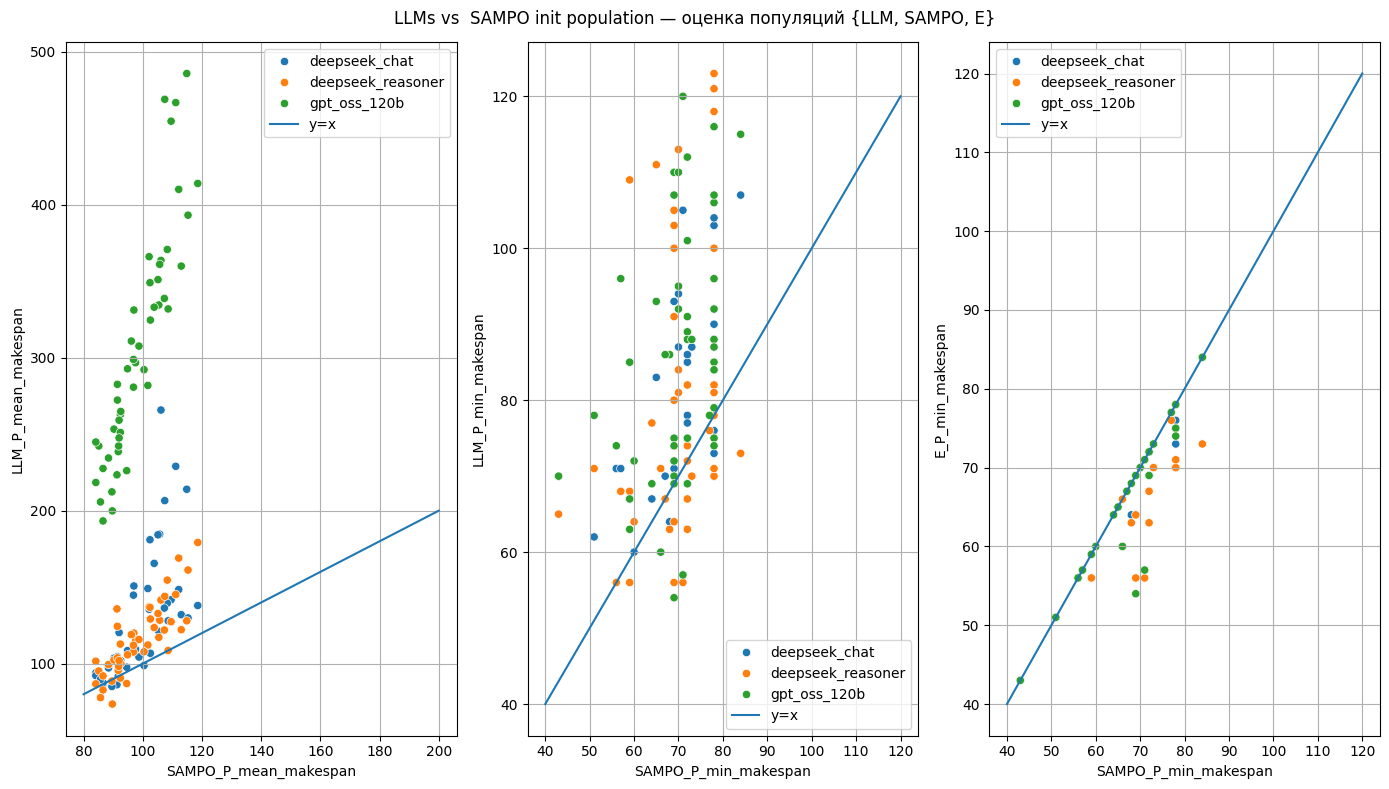

In [22]:
import seaborn as sns
plt.rcParams['axes.grid'] = True
fig, axes = plt.subplots(1, 3, figsize=(14, 8),)

fig.suptitle('LLMs vs  SAMPO init population \u2014 оценка популяций {LLM, SAMPO, E}' )

sns.scatterplot(data=df, x ='SAMPO_P_mean_makespan', y='LLM_P_mean_makespan',hue='LLM_used', ax=axes[0],)
sns.lineplot(x = [80, 200], y =[80, 200], ax=axes[0], label='y=x')

sns.scatterplot(data=df, x ='SAMPO_P_min_makespan', y='LLM_P_min_makespan', hue='LLM_used', ax=axes[1])
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[1],label='y=x')

sns.scatterplot(data=df, x ='SAMPO_P_min_makespan', y='E_P_min_makespan', hue='LLM_used', ax=axes[2],)
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[2],label='y=x')



plt.tight_layout()